# Inferência Bayesiana

<hr>

Inferência Bayesiana usando o pacote PyMC . <br>
https://www.pymc.io/projects/docs/en/stable/learn.html

Resumo dos Conceitos Fundamentais

A inferência Bayesiana é um paradigma estatístico que interpreta probabilidade como um grau de crença ou incerteza.

Isso difere da visão frequentista, que interpreta probabilidade como a frequência relativa em infinitas repetições.

O principal objetivo é:

> atualizar crenças à medida que novos dados são observados.

O Processo de Atualização

A inferência Bayesiana combina:

- conhecimento prévio
- evidências observadas

para produzir uma crença atualizada.

Distribuição a Priori

Representa o conhecimento sobre o parâmetro antes de observar os dados.

Notação

$$
P(\theta)
$$

Onde:

- $\theta$ = parâmetro desconhecido

```text
"O que eu acreditava
antes de ver os dados?"
```

**Verossimilhança**

Representa o quão prováveis são os dados observados dado um valor de $\theta$.

Notação

$$
P(x|\theta)
$$

**Distribuição a Posteriori**

Representa a crença atualizada após observar os dados.

Notação

$$
P(\theta|x)
$$

Fluxo Mental da Inferência Bayesiana

```text
Priori
↓
Observação de dados
↓
Atualização
↓
Posteriori
```

##### Relevância para Data Science

**Incorporar Conhecimento Prévio**

A inferência Bayesiana permite incluir:

- conhecimento de especialistas
- estudos anteriores
- informações históricas

através da distribuição a priori.


## Lançamento de uma moeda

Considere o lançamento de uma moeda n vezes e anote caras como 1 e coroas com 0.

A probabilidade de sair cara $p$ não é conhecida e desejamos estimá-la a partir de uma amostra coletada. Na inferência frequentista, usamos máxima verossimilhança, que nesse caso é igual ao número de caras obtido divido pelo total de lançamentos $n$. Vamos gerar os dados do lançamento usando a biblioteca numpy.

X: [0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0.
 0. 1.]


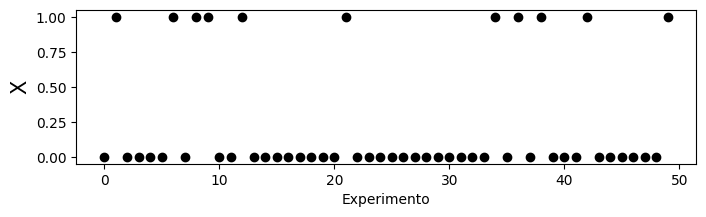

In [19]:
#import warnings
#warnings.filterwarnings('ignore')
from matplotlib import pyplot as plt
import numpy as np
np.random.seed(10)
# probabilidade de sair cara
theta_pop = 0.2
n = 50 # número de lançamentos
X = np.zeros(n)
for i in range(0,n):
    if(np.random.uniform() <= theta_pop):
        X[i] = 1
theta_hat_freq = np.sum(X)/len(X)
print('X:',X)
plt.figure(figsize=(8,2))
plt.plot(range(0,n), X, 'ko')
plt.xlabel('Experimento', fontsize = 10)
plt.ylabel('X',fontsize = 15)
plt.savefig('bayes-coin.svg')
plt.show(True)

Usando inferência Bayesiana, realizamos a estimação pontual usando MAP e construímos um intervalo de credibilidade.

O MAP corresponde ao valor de maior densidade da posteriori.

Fórmula

$$
\hat{\theta}_{MAP} =
\arg\max_{\theta} P(\theta|x)
$$

Intuição

```text
Valor mais provável
após observar os dados.
```

In [20]:
import pymc as pm

with pm.Model() as model:
    # define a distribuição a priori
    # vamos usar uma distribuição beta
    theta = pm.Beta('theta', 2, 2)

    # define a função de verossimilhança
    observation = pm.Bernoulli('obs', theta, observed=X)

    # obtém as amostras
    step = pm.Metropolis()
    trace = pm.sample(10000, tune=5000, step=step, return_inferencedata=True)

Output()

Output()

O estimador pontual usando MAP:

In [21]:
map_estimate = pm.find_MAP(model=model)
print(map_estimate)

Output()

{'theta_logodds__': array(-1.20397279), 'theta': array(0.23076923)}


Podemos então visualizar a distribuição a posteriori e o intervalo de credibilidade de 95% usando o método HPD (highest posterior density).

<Axes: title={'center': 'theta'}>

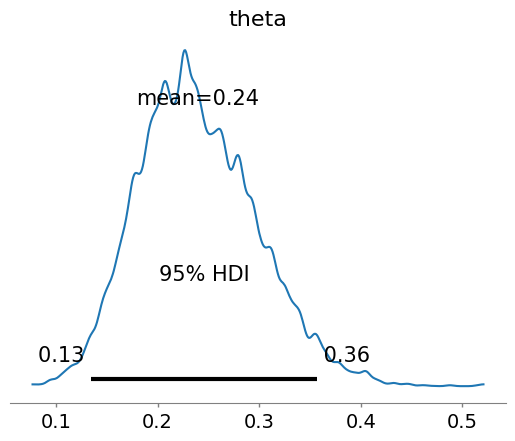

In [22]:
import arviz as az
from matplotlib import pyplot as plt
az.plot_posterior(trace, hdi_prob=0.95)

Portanto, podemos dizer que com probabilidade de 95%, o parâmetro está dentro do intervalo indicado na figura.

## Inferência para uma população normal

Suponha que temos uma amostra obtida a partir de uma distribuição normal $X \sim \mathcal{N}(\mu, \sigma)$. Vamos estimar os valores de $\mu$ e $\sigma$, ambos desconhecidos. Consideramos prioris não informativas para os dois parâmetros, ou seja, ambos com distribuições a priori uniformes.

Text(0, 0.5, 'P(x)')

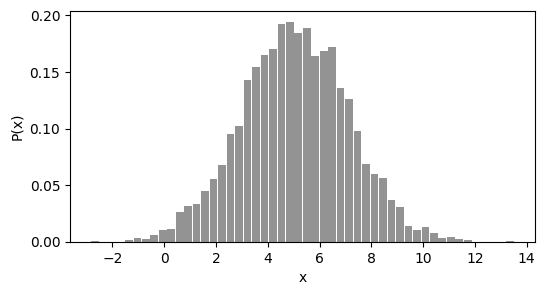

In [24]:
import numpy as np
%matplotlib inline
from matplotlib import pyplot as plt
np.random.seed(101)
# gera os dados
N = 5000 # tamanho da população
mu_pop = 5
stdev_pop = 2
data = np.random.normal(mu_pop,stdev_pop, N)
# mostra a distribuição dos dados
plt.figure(figsize=(6, 3))
plt.hist(data, rwidth=0.9, bins='auto',
         alpha=0.85,color="gray", density=True)
plt.xlabel("x", fontsize = 10)
plt.ylabel("P(x)", fontsize = 10)

In [25]:
data

array([10.41369968,  6.25626542,  6.81593889, ...,  3.50951218,
        8.00617673,  2.45599935])

Output()

/usr/local/lib/python3.11/dist-packages/pymc/step_methods/metropolis.py:318: RuntimeWarning: overflow encountered 
in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),

Output()

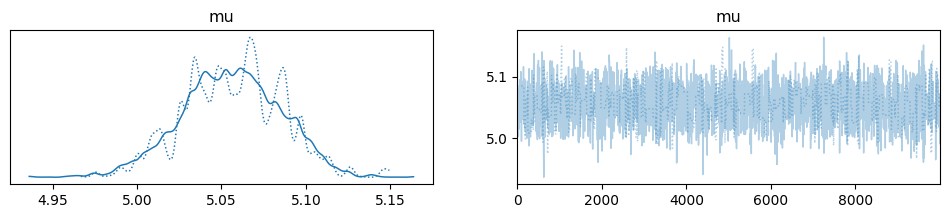

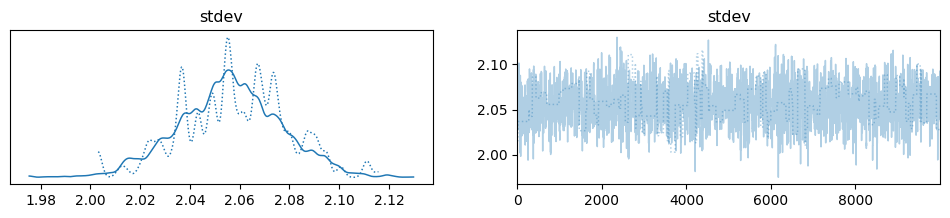

array([<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'stdev'}>],
      dtype=object)

<Figure size 1000x500 with 0 Axes>

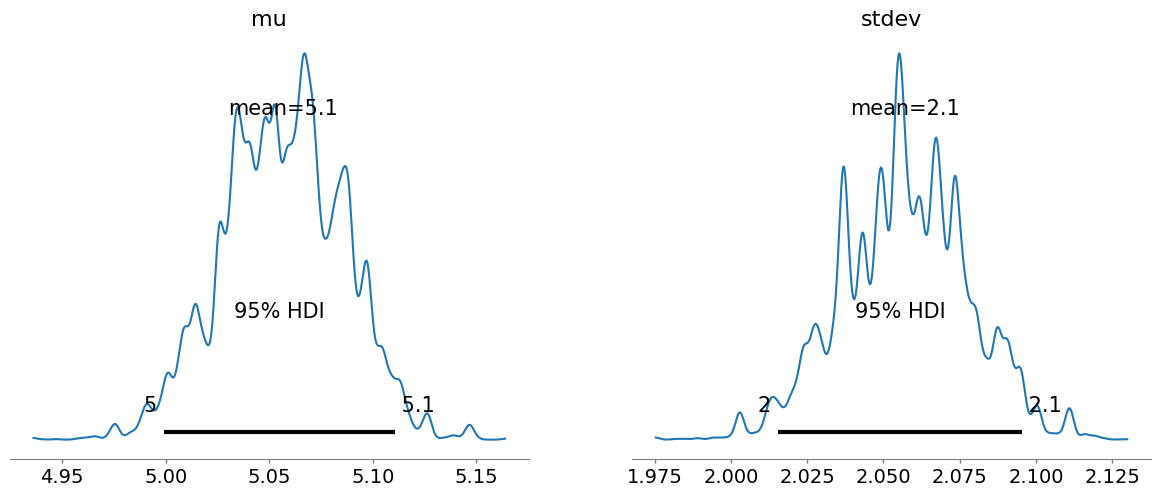

In [7]:
import pymc as pm
import arviz as az
from matplotlib import pyplot as plt

with pm.Model() as model:
    # define as distribuições a priori
    mu = pm.Normal('mu', mu = 0.0,sigma = 20)
    stdev = pm.HalfNormal('stdev', sigma=10)
    # função de verossimilhança
    observation = pm.Normal('obs', mu=mu, sigma=stdev,observed=data)
    # realiza a inferência
    #trace = pm.sample(1000)
    step = pm.Metropolis()
    trace = pm.sample(draws = 10000, tune=5000,
                      step=step, return_inferencedata=True)
    # Mostra os resultados
    pm.plot_trace(trace,['mu'])
    pm.plot_trace(trace,['stdev'])
    plt.show(True)
# mostra as distribuições a posteriori
plt.figure(figsize=(10, 5))
az.plot_posterior(trace, hdi_prob=0.95)

É importante comentar que a escolha dos hiperparâmetros influencia nos resultados. No exemplo anterior, se tivermos poucos dados e o desvio padrão da distribuição normal for muito pequeno,  pode ser que não consigamos estimar a média populacional de forma precisa.  Assim,  é importante fazer um estudo cuidado para que os hiperparâmetros sejam escolhidos da melhor forma possível. Uma possibilidade é utilizar métodos de validação cruzada. O leitor interessado pode consultar:
https://github.com/CamDavidsonPilon/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers

No exemplo anterior, se mudarmos as prioris e tivermos um conjunto menor de dados, vemos que a estimação não é tão precisa.

Output()

Output()

array([<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'stdev'}>],
      dtype=object)

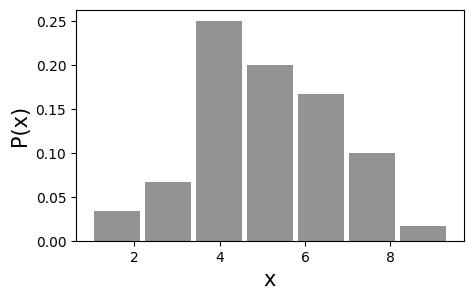

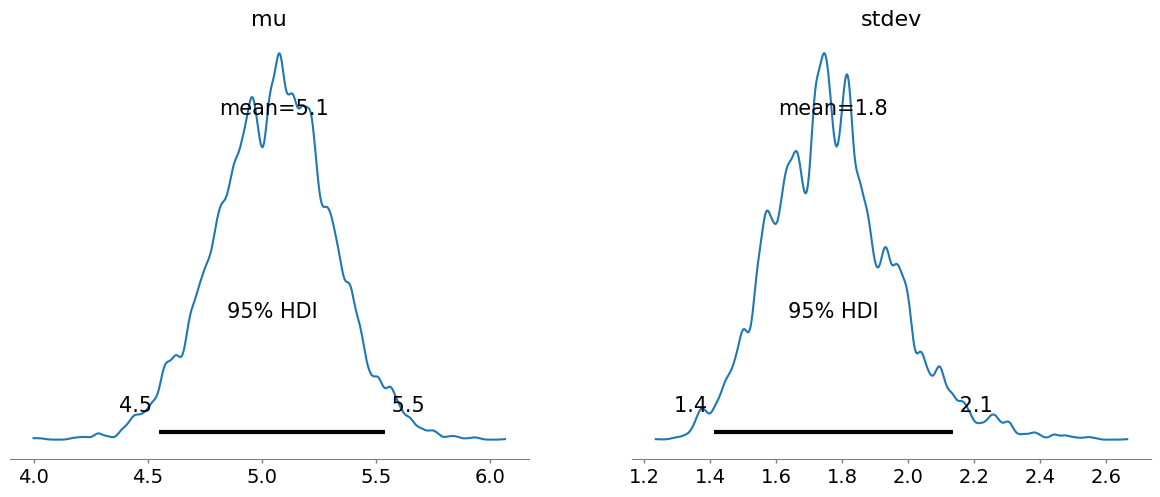

In [26]:
import pymc as pm
import arviz as az
from matplotlib import pyplot as plt
import numpy as np

# generate observed data
N = 50
mu_pop = 5
stdev_pop = 2
data = np.random.normal(mu_pop,stdev_pop, N)

plt.figure(figsize=(5, 3))
plt.hist(data, rwidth=0.9, bins='auto', alpha=0.85,color="gray", density=True)
plt.xlabel("x", fontsize = 15)
plt.ylabel("P(x)", fontsize = 15)

with pm.Model() as model:
    # define priors
    mu = pm.Normal('mu', mu = 0.0,sigma = 0.5)
    stdev = pm.HalfNormal('stdev', sigma=0.5)
    # define likelihood
    observations = pm.Normal('obs', mu=mu, sigma=stdev, observed=data)
    # inference
    step = pm.Metropolis()
    trace = pm.sample(draws = 10000, tune=5000, step=step, return_inferencedata=True)

az.plot_posterior(trace, hdi_prob=0.95)

Observamos que o modelo não é capaz de predizer o valor real da média populacional.

## Dados de contagem

Vamos simular a entrade de pessoas em uma loja ao longo de $n$ dias. Como esses são dados de contagem, geramos os dados de acordo com uma distribuição de Poisson com parâmetro $\lambda$. Vamos assumir que temos acesso apenas aos dados anotados e não conhecemos o valor de $\lambda$. Usando inferência Bayesiana vamos estimar $\lambda$ usando a biblioteca PyMC.

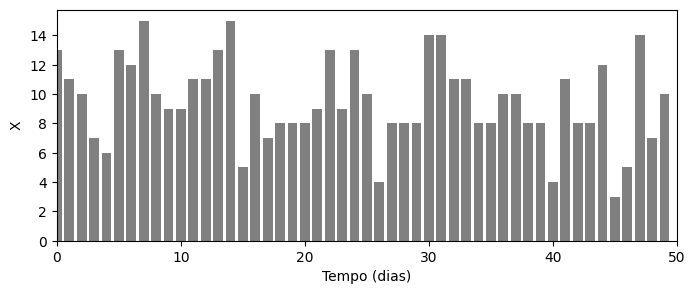

In [29]:
#Reset all variables
from IPython import get_ipython;
get_ipython().magic('reset -sf')

%matplotlib inline
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import poisson
np.random.seed(10)
# lambda da população
lambda_pop = 10
N = 50 # tamanho da amostra
count_data = poisson.rvs(mu=lambda_pop, size=N)
n_count_data = len(count_data)
# mostra os dados gerados
plt.figure(figsize=(8,3))
plt.bar(np.arange(n_count_data), count_data,
        color="gray")
plt.xlabel("Tempo (dias)",fontsize=10)
plt.ylabel("X", fontsize=10)
plt.xlim(0, n_count_data);
plt.show(True)

In [28]:
count_data

array([13, 11, 10,  7,  6, 13, 12, 15, 10,  9,  9, 11, 11, 13, 15,  5, 10,
        7,  8,  8,  8,  9, 13,  9, 13, 10,  4,  8,  8,  8, 14, 14, 11, 11,
        8,  8, 10, 10,  8,  8,  4, 11,  8,  8, 12,  3,  5, 14,  7, 10])

Text(0, 0.5, 'P(k)')

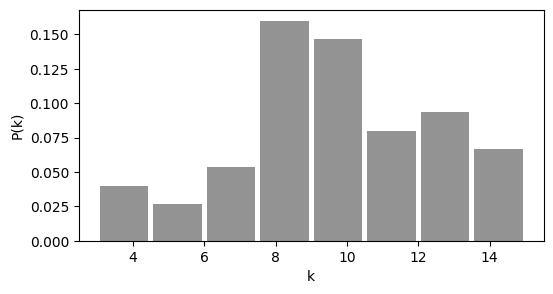

In [10]:
from matplotlib import pyplot as plt

plt.figure(figsize=(6,3))
plt.hist(count_data, rwidth=0.9, bins='auto', alpha=0.85,color="gray", density=True)
plt.xlabel("k", fontsize = 10)
plt.ylabel("P(k)", fontsize = 10)

No modelo que estamos considerando, $\lambda$ é desconhecido. Desse modo, associamos uma distribuição a priori para $\lambda$. Como $\lambda$ tem que ser um valor positivo $\lambda \geq 0$, podemos assumir que $\lambda$ tem uma distribuição a priori exponencial com parâmetro $\alpha$, que é um hiperparâmetro do modelo. Uma escolha adequada para esse valor seria a média das medições e assim evitamos uma arbitrariedade na sua escolha.

Output()

Output()

<Axes: title={'center': 'lambda1'}>

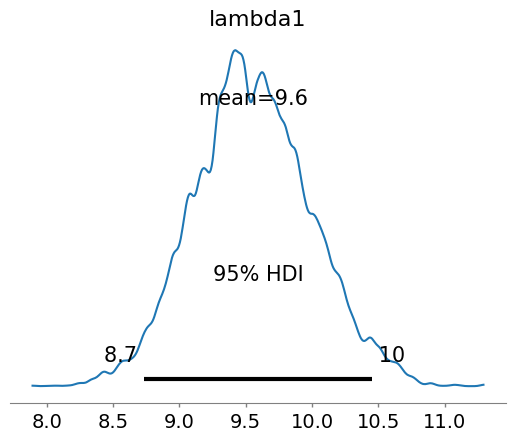

In [11]:
import pymc as pm
import arviz as az

with pm.Model() as model:
    # define as distribuições a priori
    alpha = 1.0/np.mean(count_data)
    lambda1 = pm.Exponential("lambda1", alpha)
    #lambda1 = pm.Uniform("lambda1", lower=0, upper= np.max(count_data))

    # função de verossimilhança
    observation = pm.Poisson('obs', lambda1, observed=count_data)

    # obtém as amostras
    #trace = pm.sample(return_inferencedata=True)
    step = pm.Metropolis()
    trace = pm.sample(10000, tune=5000, step=step, return_inferencedata=True)
    idata = pm.sample_prior_predictive(draws=100)

# mostra a distribuição a posteriori
az.plot_posterior(trace, hdi_prob=0.95)

A estatística dos valores estimados.

In [12]:
pm.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lambda1,9.552,0.438,8.701,10.35,0.007,0.005,3880.0,3909.0,1.0


Vamos comparar a distribuição dos dados originais com uma distribuição obtida a partir da posteriori.

Output()

Output()

Output()

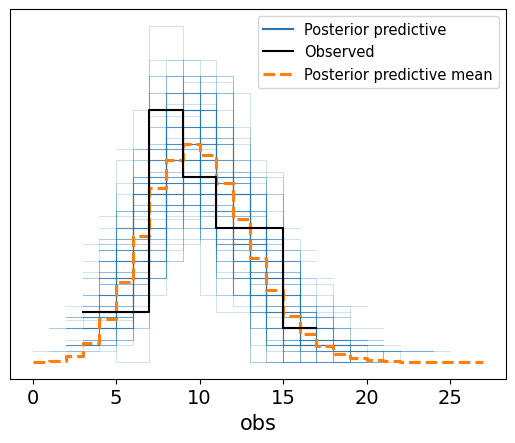

In [13]:
with model:
    idata.extend(pm.sample(1000, tune=2000))

with model:
    pm.sample_posterior_predictive(idata, extend_inferencedata=True)
az.plot_ppc(idata, num_pp_samples=100);

## Regressão Linear

Vamos supor que um modelo estatístico gera um conjunto de dados. Os parâmetros do modelo são desconhecidos e só conseguimos medir os dados de saída, que apresentam um certo nível de ruído. Assim, o modelo gerador dos dados é dado por:
$$
y_{model} = \beta_0 + \beta_1 x
$$
E os dados observados:
$$
y = y_{model}+N(0,\sigma)
$$
Onde $N(0,\sigma)$ representa o erro na medição. Nosso objetivo é estimar os valores dos parâmetros do modelo ($\beta_0, \beta_1$), baseando-se em um conjunto de dados coletados.

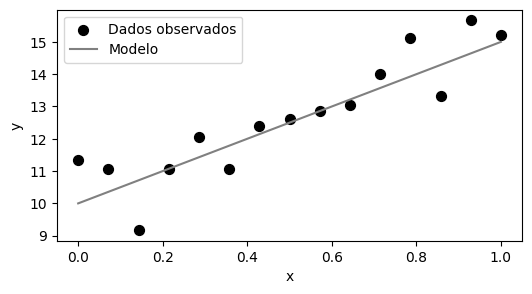

In [14]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(10)

# parâmetros do modelo
beta_0_model = 10
beta_1_model = 5
sigma_model = 1
# número de observações
num_points = 15
# gera os dados
x = np.linspace(0, 1, num_points)
y_model = beta_0_model + beta_1_model*x
y = y_model + np.random.normal(scale=sigma_model,
                               size=num_points)
# mostra os dados e o modelo
plt.figure(figsize=(6,3))
plt.scatter(x, y, s=50,c='k',
            label = 'Dados observados')
plt.plot(x, y_model, color='gray',
         label = 'Modelo')
plt.xlabel('x', fontsize=10)
plt.ylabel('y', fontsize=10)
plt.legend(fontsize = 10)
plt.show(True)

Inicialmente, vamos fazer a regressão usando estatística frequentista, que usa o método da máxima verossimilhança.

Modelo real:
y_true = 10 + 5*x
Sigma real: 1

Modelo estimado:
y_hat = 10.114162632182026 + 5.108472760004521*x
desvio padrão dos resíduos: 0.771321058301734


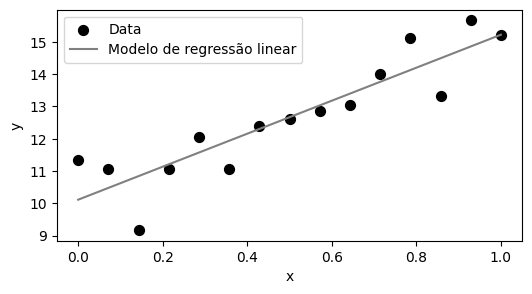

In [15]:
from sklearn.linear_model import LinearRegression

clf = LinearRegression()
clf.fit(x.reshape(-1,1), y)
preds = clf.predict(x.reshape(-1,1))
resids = preds - y

true_params = {'beta_0': beta_0_model,
               'beta_1': beta_1_model,
               'sigma': sigma_model}

print('Modelo real:')
print('y_true = %s + %s*x'%(beta_0_model, beta_1_model))
print('Sigma real: %s\n'%true_params['sigma'])

print('Modelo estimado:')
print('y_hat = %s + %s*x'%(clf.intercept_, clf.coef_[0]))
print('desvio padrão dos resíduos: %s'%(resids.std()))
# ajusta o modelo
mle_estimates = {'beta_0': clf.intercept_, 'beta_1': clf.coef_[0],  'sigma': resids.std()}
y_LR = clf.intercept_ + clf.coef_[0]*x
# mostra o modelo de regressão
plt.figure(figsize=(6,3))
plt.scatter(x, y, s=50,c='k', label = 'Data')
plt.plot(x, y_LR, color='gray', label = 'Modelo de regressão linear')
plt.xlabel('x', fontsize=10)
plt.ylabel('y', fontsize=10)
plt.legend(fontsize = 10)
plt.show(True)

Vamos agora ajustar o modelo Bayesiano. Assumimos como prioris:
$$
\beta_0 \sim \mathcal{N}(0,20)
$$
$$
\beta_1 \sim \mathcal{N}(0,20)
$$
$$
\sigma \sim Exp(1)
$$
A posteriori:
$$
P(\beta_0,\beta_1,\sigma|y) \propto P(y|\beta_0,\beta_1,\sigma)P(\beta_0)P(\beta_1)P(\sigma)
$$

Output()

array([<Axes: title={'center': 'beta_0'}>,
       <Axes: title={'center': 'beta_1'}>,
       <Axes: title={'center': 'sigma'}>], dtype=object)

<Figure size 1000x500 with 0 Axes>

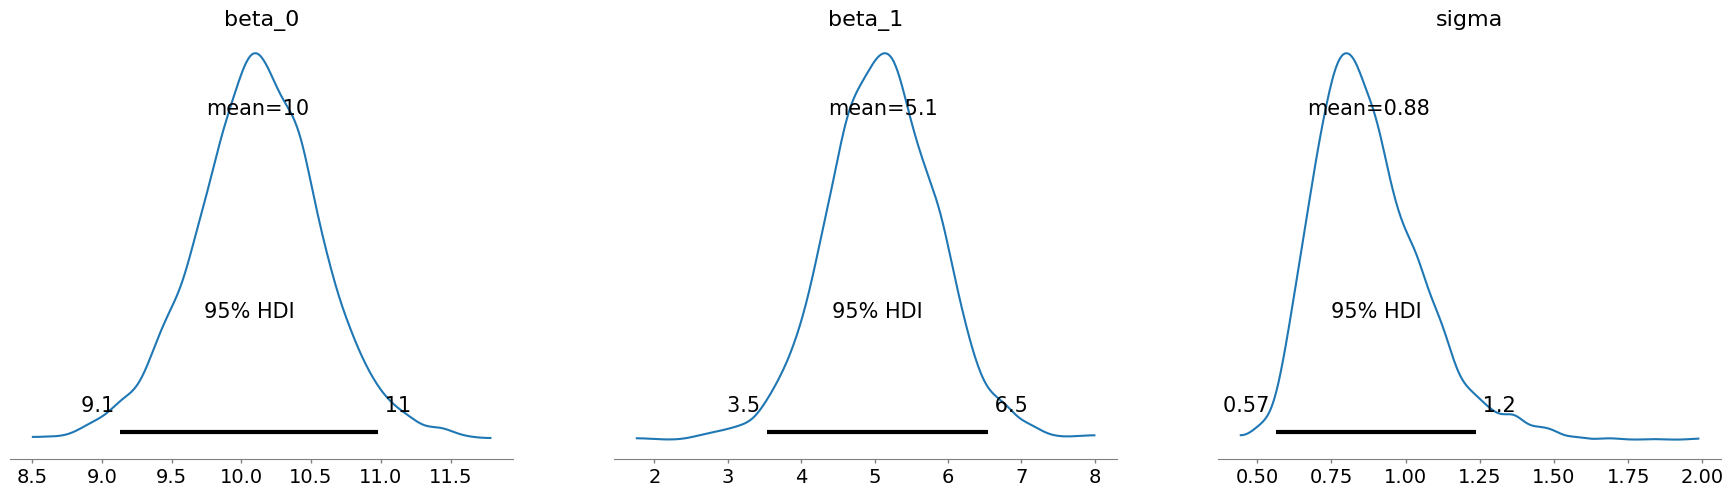

In [16]:
import pymc as pm
import arviz as az

with pm.Model() as model:
    # distribuições a priori
    sigma = pm.Exponential("sigma", lam = 1.0)
    beta_0 = pm.Normal("beta_0", mu=0, sigma=20)
    beta_1 = pm.Normal("beta_1", mu=0, sigma=20)
    # Verossimilhança
    observations = pm.Normal("obs",mu=beta_0 + beta_1*x,
                             sigma=sigma, observed=y)
    # Faz a estimação
    trace = pm.sample(1000, cores=4)

# mostra as distribuições a posteriori
plt.figure(figsize=(10, 5))
az.plot_posterior(trace, hdi_prob=0.95)

Output()

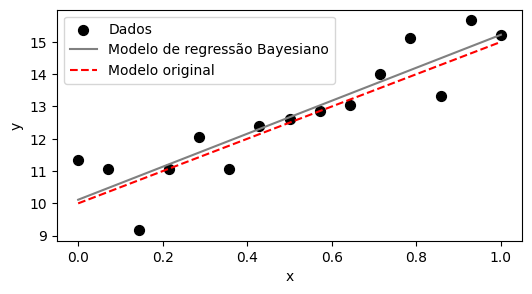

In [17]:
# modelo ajustado
map_estimate = pm.find_MAP(model=model)
y_Bayes = map_estimate['beta_0'] + map_estimate['beta_1']*x

plt.figure(figsize=(6,3))
plt.scatter(x, y, s=50,c='k', label = 'Dados')
plt.plot(x, y_Bayes, color='gray',
         label = 'Modelo de regressão Bayesiano')
plt.plot(x, y_model, color='red',linestyle='dashed',
         label = 'Modelo original')
plt.xlabel('x', fontsize=10)
plt.ylabel('y', fontsize=10)
plt.legend(fontsize = 10)
plt.show(True)

Comparando os modelos em termos do erro quadrático médio:

In [18]:
from sklearn.metrics import mean_squared_error

print('Linear regression error:', mean_squared_error(y_LR, y))
print('Bayesian linear regression error:', mean_squared_error(y_Bayes, y))

Linear regression error: 0.5949361749797067
Bayesian linear regression error: 0.5949370868306776


### Leitura complementar

https://www.pymc.io/projects/docs/en/stable/learn/core_notebooks/pymc_overview.html

https://people.duke.edu/~ccc14/sta-663/PyMC3.html

https://github.com/CamDavidsonPilon/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers